# Hand Gesture Presentation Controller Pipeline

This notebook implements the five-phase plan captured in `pipeline.md` so we can go from Roboflow Pascal VOC annotations to a deployable hand-gesture presentation controller.

- **Phase 1:** Parse VOC XML files and crop gesture ROIs into a clean dataset structure.
- **Phase 2:** Convert crops into fixed-length HOG descriptors.
- **Phase 3:** Train and evaluate a conventional classifier (linear/RBF SVM).
- **Phase 4:** Connect the classifier to a webcam ROI + `pyautogui` control loop.
- **Phase 5:** Collect artifacts for the written report and demo video.

## Workspace Checklist
- Code runs from the repo root: `HandGesturePresentationController/`.
- Raw Pascal VOC data lives under `Dataset_roboflow/{train,valid,test}`.
- Cropped conventional dataset will be stored in `dataset_final/{split}/{label}` (mirrors Phase 1 of the pipeline).
- Fallback conventional data (if any) can be read from the legacy `Dataset/{Back,Next}` directories.
- Artifacts (CSV manifests, trained models, charts) are saved inside `artifacts/` for report inclusion.


In [ ]:
from pathlib import Path
from typing import Dict, Iterable, List, Sequence, Tuple
import xml.etree.ElementTree as ET

import cv2
import numpy as np
import pandas as pd
from PIL import Image
from skimage.feature import hog
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
import joblib

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_rows", 10)

BASE_DIR = Path.cwd()
ROBOFLOW_DATASET = BASE_DIR / "Dataset_roboflow"
PROCESSED_DATASET = BASE_DIR / "dataset_final"
FALLBACK_DATASET = BASE_DIR / "Dataset"
ARTIFACTS_DIR = BASE_DIR / "artifacts"
MODEL_BUNDLE_PATH = ARTIFACTS_DIR / "gesture_svm_v3.pkl"

SPLITS: Sequence[str] = ("train", "valid", "test")
ALLOWED_IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp"}
TARGET_IMAGE_SIZE: Tuple[int, int] = (128, 128)

# Canny Edge Detection Parameters
CANNY_PARAMS: Dict[str, object] = {
    "threshold1": 50,  # Lower threshold for edge linking
    "threshold2": 150,  # Upper threshold for edge detection
    "apertureSize": 3,  # Sobel kernel size (3, 5, or 7)
    "L2gradient": True,  # Use L2 norm for gradient magnitude (more accurate)
}

# HOG Feature Extraction Parameters
HOG_PARAMS: Dict[str, object] = {
    "orientations": 9,
    "pixels_per_cell": (16, 16),
    "cells_per_block": (2, 2),
    "transform_sqrt": True,
    "block_norm": "L2-Hys",
    "feature_vector": True,
}

LABEL_MAP = {"next": "next", "back": "previous", "prev": "previous"}
RANDOM_STATE = 42

ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DATASET.mkdir(parents=True, exist_ok=True)

print(f"Project root: {BASE_DIR}")
print(f"Roboflow dataset: {ROBOFLOW_DATASET.exists()} | Processed dataset: {PROCESSED_DATASET.exists()}")

Project root: c:\Users\Lenovo\Documents\CODING\Python\computer_vision\HandGesturePresentationController
Roboflow dataset: True | Processed dataset: True


## Phase 1 - Data Pre-processing (XML Parsing + Cropping)
Goals:
- Parse every Pascal VOC XML from Roboflow (`Dataset_roboflow`) and extract bounding boxes.
- Normalize labels (`next`, `back` -> `previous`).
- Crop the gesture region, optionally adding a small padding, and save it under `dataset_final/{split}/{label}` as required by `pipeline.md`.
- Produce a CSV manifest that can be cited in the report (counts per split/label, augmentation notes, etc.).


In [3]:
def parse_annotation_file(xml_path: Path) -> List[Dict[str, int]]:
    """Return all bounding boxes defined in a Pascal VOC XML file."""
    try:
        tree = ET.parse(xml_path)
    except ET.ParseError as exc:
        raise ValueError(f"Failed to parse {xml_path}: {exc}") from exc

    root = tree.getroot()
    objects: List[Dict[str, int]] = []
    for obj in root.findall("object"):
        raw_label = obj.findtext("name", default="").strip().lower()
        bbox = obj.find("bndbox")
        if not raw_label or bbox is None:
            continue
        xmin = int(float(bbox.findtext("xmin", default="0")))
        xmax = int(float(bbox.findtext("xmax", default="0")))
        ymin = int(float(bbox.findtext("ymin", default="0")))
        ymax = int(float(bbox.findtext("ymax", default="0")))
        objects.append({"label": raw_label, "xmin": xmin, "ymin": ymin, "xmax": xmax, "ymax": ymax})
    return objects


def resolve_image_for_xml(xml_path: Path) -> Path:
    """Find the image file that shares the same stem as the XML annotation."""
    candidates = [xml_path.with_suffix(ext) for ext in (".jpg", ".jpeg", ".png", ".bmp")]
    for candidate in candidates:
        if candidate.exists():
            return candidate
    raise FileNotFoundError(f"No image file found for {xml_path}")


def collect_crop_jobs(split_dir: Path) -> List[Dict[str, object]]:
    jobs: List[Dict[str, object]] = []
    for xml_path in sorted(split_dir.glob("*.xml")):
        image_path = resolve_image_for_xml(xml_path)
        for obj in parse_annotation_file(xml_path):
            normalized_label = LABEL_MAP.get(obj["label"], None)
            if normalized_label is None:
                continue
            jobs.append(
                {
                    "split": split_dir.name,
                    "label": normalized_label,
                    "image_path": image_path,
                    "xmin": obj["xmin"],
                    "ymin": obj["ymin"],
                    "xmax": obj["xmax"],
                    "ymax": obj["ymax"],
                }
            )
    return jobs


def crop_hand(job: Dict[str, object], output_root: Path, pad_ratio: float = 0.08) -> Path:
    image = Image.open(job["image_path"]).convert("RGB")
    width, height = image.size
    w = job["xmax"] - job["xmin"]
    h = job["ymax"] - job["ymin"]
    pad_w = int(w * pad_ratio)
    pad_h = int(h * pad_ratio)
    x0 = max(0, job["xmin"] - pad_w)
    y0 = max(0, job["ymin"] - pad_h)
    x1 = min(width, job["xmax"] + pad_w)
    y1 = min(height, job["ymax"] + pad_h)
    crop = image.crop((x0, y0, x1, y1))

    dest_dir = output_root / job["split"] / job["label"]
    dest_dir.mkdir(parents=True, exist_ok=True)
    dest_path = dest_dir / f"{job['split']}_{job['label']}_{job['image_path'].stem}_{x0}_{y0}_{x1}_{y1}.jpg"
    crop.save(dest_path)
    return dest_path


def run_phase_one(execute: bool = False, pad_ratio: float = 0.08) -> pd.DataFrame:
    """Optionally crop all annotations and return a manifest DataFrame."""
    all_jobs: List[Dict[str, object]] = []
    for split in SPLITS:
        split_dir = ROBOFLOW_DATASET / split
        if not split_dir.exists():
            continue
        all_jobs.extend(collect_crop_jobs(split_dir))

    if not all_jobs:
        raise FileNotFoundError("No Pascal VOC annotations were found. Verify Dataset_roboflow/ is populated.")

    print(f"Located {len(all_jobs)} bounding boxes across {len(set(job['split'] for job in all_jobs))} splits.")
    if not execute:
        print("Dry run mode: set execute=True to create/refresh dataset_final/.")
        return pd.DataFrame(all_jobs)

    cropped_records: List[Dict[str, object]] = []
    for job in all_jobs:
        dest_path = crop_hand(job, PROCESSED_DATASET, pad_ratio=pad_ratio)
        record = {**job, "crop_path": dest_path.as_posix()}
        cropped_records.append(record)

    manifest = pd.DataFrame(cropped_records)
    manifest.to_csv(ARTIFACTS_DIR / "crop_manifest.csv", index=False)
    print(f"Saved {len(manifest)} crops -> {ARTIFACTS_DIR / 'crop_manifest.csv'}")
    return manifest


In [4]:
CROP_DATA = True  # Switch to True when you are ready to refresh dataset_final/
phase_one_manifest = run_phase_one(execute=CROP_DATA, pad_ratio=0.08)

if phase_one_manifest is not None:
    display(phase_one_manifest.head())


Located 407 bounding boxes across 3 splits.
Saved 407 crops -> c:\Users\Lenovo\Documents\CODING\Python\computer_vision\HandGesturePresentationController\artifacts\crop_manifest.csv


,split,label,image_path,xmin,ymin,xmax,ymax,crop_path
0,train,next,c:\Users\Lenovo\Documents\CODING\Python\comput...,22,240,428,393,c:/Users/Lenovo/Documents/CODING/Python/comput...
1,train,next,c:\Users\Lenovo\Documents\CODING\Python\comput...,86,240,492,393,c:/Users/Lenovo/Documents/CODING/Python/comput...
2,train,next,c:\Users\Lenovo\Documents\CODING\Python\comput...,86,240,492,393,c:/Users/Lenovo/Documents/CODING/Python/comput...
3,train,next,c:\Users\Lenovo\Documents\CODING\Python\comput...,130,152,357,311,c:/Users/Lenovo/Documents/CODING/Python/comput...
4,train,next,c:\Users\Lenovo\Documents\CODING\Python\comput...,157,152,384,311,c:/Users/Lenovo/Documents/CODING/Python/comput...


## Phase 2 - Feature Extraction (Grayscale + Resize + HOG)
Goals:
- Load every cropped image, convert to grayscale, and resize to the fixed `128x128` target required by SVM.
- Extract HOG descriptors using the parameters defined in `HOG_PARAMS`.
- Persist the feature matrix (NumPy `.npz`) and a metadata table (CSV) so we can reuse them without recomputing.
- Produce quick sanity-check visuals/statistics for the written report.


In [5]:
def dataset_has_images(root: Path) -> bool:
    if not root.exists():
        return False
    return any(root.rglob("*.jpg")) or any(root.rglob("*.png"))


def resolve_feature_dataset_root(preferred: Path, fallback: Path) -> Path:
    if dataset_has_images(preferred):
        return preferred
    if dataset_has_images(fallback):
        print(f"Warning: {preferred} is empty; using fallback {fallback}")
        return fallback
    raise FileNotFoundError("No cropped dataset found. Run Phase 1 or place images under Dataset/.")


def iter_image_paths(dataset_root: Path, splits: Sequence[str] | None = None):
    has_split_structure = any((dataset_root / split).exists() for split in SPLITS)
    if has_split_structure:
        target_splits = splits if splits else [p.name for p in dataset_root.iterdir() if p.is_dir()]
        for split in target_splits:
            split_dir = dataset_root / split
            if not split_dir.exists():
                continue
            for label_dir in sorted(p for p in split_dir.iterdir() if p.is_dir()):
                for image_path in sorted(label_dir.iterdir()):
                    if image_path.suffix.lower() in ALLOWED_IMAGE_EXTS:
                        yield split, label_dir.name.lower(), image_path
    else:
        for label_dir in sorted(p for p in dataset_root.iterdir() if p.is_dir()):
            for image_path in sorted(label_dir.iterdir()):
                if image_path.suffix.lower() in ALLOWED_IMAGE_EXTS:
                    yield "all", label_dir.name.lower(), image_path


def compute_canny_hog_descriptor(
    image_path: Path, 
    target_size: Tuple[int, int], 
    canny_params: Dict[str, object],
    hog_params: Dict[str, object]
) -> np.ndarray:
    """
    Combines Canny edge detection with HOG descriptor extraction.
    
    Pipeline:
    1. Load and resize image to target_size
    2. Convert to grayscale
    3. Apply Canny edge detection to extract edges
    4. Compute HOG features on the edge-detected image
    5. Flatten Canny edge map and concatenate with HOG features
    
    Returns:
        Combined feature vector (Canny edges + HOG)
    """
    # Load, convert to grayscale, and resize
    image = Image.open(image_path).convert("L").resize(target_size)
    image_arr = np.asarray(image, dtype=np.uint8)
    
    # Apply Canny edge detection
    edges = cv2.Canny(
        image_arr,
        threshold1=canny_params["threshold1"],
        threshold2=canny_params["threshold2"],
        apertureSize=canny_params["apertureSize"],
        L2gradient=canny_params["L2gradient"]
    )
    
    # Normalize edge map for HOG computation
    edges_normalized = edges.astype(np.float32) / 255.0
    
    # Compute HOG on the edge-detected image
    hog_features = hog(edges_normalized, **hog_params)
    
    # Flatten the Canny edge map and normalize its magnitude
    canny_flat = edges.flatten().astype(np.float32) / 255.0
    
    # Concatenate both feature sets
    combined_features = np.concatenate([hog_features, canny_flat])
    
    return combined_features


def build_feature_set(
    dataset_root: Path,
    target_size: Tuple[int, int],
    canny_params: Dict[str, object],
    hog_params: Dict[str, object],
    splits: Sequence[str] | None = None,
    persist: bool = True,
) -> Tuple[np.ndarray, pd.DataFrame]:
    records: List[Dict[str, object]] = []
    feature_rows: List[np.ndarray] = []

    for split_name, label_name, image_path in iter_image_paths(dataset_root, splits=splits):
        descriptor = compute_canny_hog_descriptor(image_path, target_size, canny_params, hog_params)
        feature_rows.append(descriptor)
        records.append({
            "split": split_name,
            "label": LABEL_MAP.get(label_name, label_name),
            "image_path": image_path.as_posix(),
        })

    if not feature_rows:
        raise ValueError(f"No eligible images found under {dataset_root}")

    feature_matrix = np.vstack(feature_rows)
    meta_df = pd.DataFrame(records)

    if persist:
        np.savez_compressed(ARTIFACTS_DIR / "canny_hog_features.npz", X=feature_matrix, y=meta_df["label"].values)
        meta_df.to_csv(ARTIFACTS_DIR / "canny_hog_metadata.csv", index=False)
        print(f"Persisted Canny+HOG features -> {ARTIFACTS_DIR / 'canny_hog_features.npz'}")
        print(f"Persisted metadata -> {ARTIFACTS_DIR / 'canny_hog_metadata.csv'}")

    return feature_matrix, meta_df


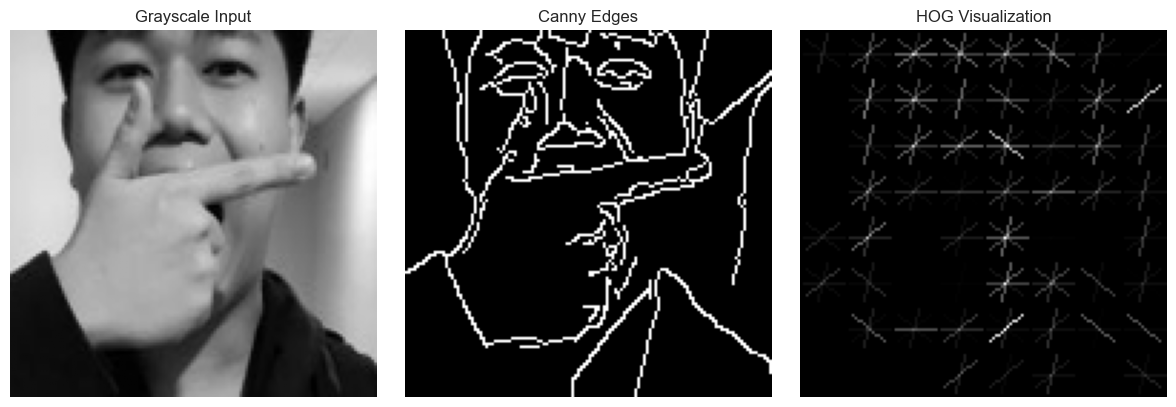

In [17]:
def visualize_canny_hog(
    image_path: Path,
    target_size: Tuple[int, int],
    canny_params: Dict[str, object],
    hog_params: Dict[str, object]
):
    # Load image
    image = Image.open(image_path).convert("L").resize(target_size)
    image_arr = np.asarray(image, dtype=np.uint8)

    # Canny edges
    edges = cv2.Canny(
        image_arr,
        threshold1=canny_params["threshold1"],
        threshold2=canny_params["threshold2"],
        apertureSize=canny_params["apertureSize"],
        L2gradient=canny_params["L2gradient"]
    )

    # HOG visualization (override visualize=True)
    hog_features, hog_image = hog(
        edges.astype(np.float32) / 255.0,
        visualize=True,
        **hog_params
    )

    # Plot results
    fig, axs = plt.subplots(1, 3, figsize=(12, 4))

    axs[0].imshow(image_arr, cmap="gray")
    axs[0].set_title("Grayscale Input")
    axs[0].axis("off")

    axs[1].imshow(edges, cmap="gray")
    axs[1].set_title("Canny Edges")
    axs[1].axis("off")

    axs[2].imshow(hog_image, cmap="gray")
    axs[2].set_title("HOG Visualization")
    axs[2].axis("off")

    plt.tight_layout()
    plt.show()

sample_image = Path("dataset_final/train/next/train_next_IMG_20251211_150846_jpg.rf.51aaa37fe3910e084cdfa20ae82e95e3_144_141_441_259.jpg")

visualize_canny_hog(
    image_path=sample_image,
    target_size=TARGET_IMAGE_SIZE,
    canny_params=CANNY_PARAMS,
    hog_params=HOG_PARAMS
)


In [6]:
feature_dataset_root = resolve_feature_dataset_root(PROCESSED_DATASET, FALLBACK_DATASET)
print(f"Using processed dataset at: {feature_dataset_root}")

X, feature_meta = build_feature_set(feature_dataset_root, TARGET_IMAGE_SIZE, CANNY_PARAMS, HOG_PARAMS, persist=True)
print(f"Feature matrix shape (Canny+HOG): {X.shape}")
print("Label distribution:\n", feature_meta["label"].value_counts())

feature_meta.head()


Using processed dataset at: c:\Users\Lenovo\Documents\CODING\Python\computer_vision\HandGesturePresentationController\dataset_final
Persisted Canny+HOG features -> c:\Users\Lenovo\Documents\CODING\Python\computer_vision\HandGesturePresentationController\artifacts\canny_hog_features.npz
Persisted metadata -> c:\Users\Lenovo\Documents\CODING\Python\computer_vision\HandGesturePresentationController\artifacts\canny_hog_metadata.csv
Feature matrix shape (Canny+HOG): (407, 18148)
Label distribution:
 label
previous    206
next        201
Name: count, dtype: int64


,split,label,image_path
0,test,next,c:/Users/Lenovo/Documents/CODING/Python/comput...
1,test,next,c:/Users/Lenovo/Documents/CODING/Python/comput...
2,test,next,c:/Users/Lenovo/Documents/CODING/Python/comput...
3,test,next,c:/Users/Lenovo/Documents/CODING/Python/comput...
4,test,next,c:/Users/Lenovo/Documents/CODING/Python/comput...


## Phase 3 - Model Training + Evaluation (SVM)
Goals:
- Split the HOG feature matrix into train/test (default 80/20 with stratification).
- Train both linear and RBF-flavored SVMs; keep the best-performing option.
- Report accuracy, precision, recall, and a confusion matrix for the written report.
- Persist the trained model (`gesture_svm.pkl`) along with preprocessing metadata for later inference.


In [7]:
from sklearn.model_selection import GridSearchCV

def train_with_grid_search(features: np.ndarray, labels: Sequence[str]):
    print("--- STARTING GRID SEARCH (This may take 1-2 minutes) ---")
    
    # 1. Define the Parameter Grid
    # We test different 'C' (strictness) and 'gamma' (curve influence)
    param_grid = [
        # Linear Kernel
        {'kernel': ['linear'], 'C': [0.1, 1, 10, 50, 100]},
        # RBF Kernel
        {'kernel': ['rbf'], 'C': [0.1, 1, 10, 50, 100], 'gamma': ['scale', 0.1, 0.01, 0.001]}
    ]

    X_train, X_test, y_train, y_test = train_test_split(
        features, labels, test_size=0.2, stratify=labels, random_state=42
    )

    # 2. Run Grid Search
    # 5-Fold Cross Validation ensures the result isn't luck
    grid = GridSearchCV(SVC(probability=True, class_weight="balanced"), param_grid, cv=5, verbose=1, n_jobs=-1)
    grid.fit(X_train, y_train)

    # 3. Best Results
    best_clf = grid.best_estimator_
    print(f"Best Parameters found: {grid.best_params_}")
    
    # 4. Final Evaluation
    y_pred = best_clf.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    
    return {
        "model": best_clf,
        "accuracy": acc,
        "report": classification_report(y_test, y_pred),
        "y_test": y_test,
        "y_pred": y_pred,
        "best_params": grid.best_params_
    }

# Execute
best_model_result = train_with_grid_search(X, feature_meta["label"].values)
print(f"Final Test Accuracy: {best_model_result['accuracy']:.2%}")
print(best_model_result["report"])

joblib.dump(
    {
        "model": best_model_result["model"],
        "hog_params": HOG_PARAMS,
        "target_size": TARGET_IMAGE_SIZE,
        "label_map": LABEL_MAP,
    },
    MODEL_BUNDLE_PATH,
)
print(f"Saved model bundle -> {MODEL_BUNDLE_PATH}")


--- STARTING GRID SEARCH (This may take 1-2 minutes) ---
Fitting 5 folds for each of 25 candidates, totalling 125 fits
Best Parameters found: {'C': 0.1, 'kernel': 'linear'}
Final Test Accuracy: 89.02%
              precision    recall  f1-score   support

        next       0.88      0.90      0.89        40
    previous       0.90      0.88      0.89        42

    accuracy                           0.89        82
   macro avg       0.89      0.89      0.89        82
weighted avg       0.89      0.89      0.89        82

Saved model bundle -> c:\Users\Lenovo\Documents\CODING\Python\computer_vision\HandGesturePresentationController\artifacts\gesture_svm_v2_Wcanny.pkl


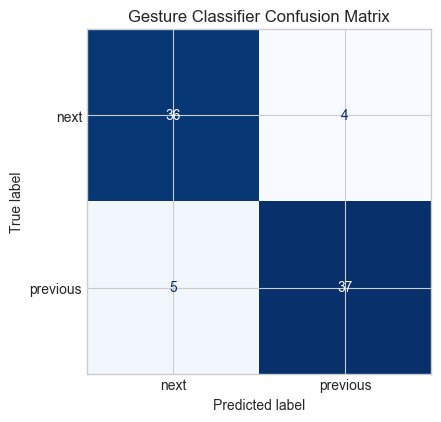

In [12]:
cm = confusion_matrix(best_model_result["y_test"], best_model_result["y_pred"], labels=best_model_result["model"].classes_)
fig, ax = plt.subplots(figsize=(4.5, 4.5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=best_model_result["model"].classes_)
disp.plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title("Gesture Classifier Confusion Matrix")
plt.tight_layout()
plt.show()


In [13]:
import time

# Recreate the exact same test split
X_train_full, X_test_full, y_train_full, y_test_full = train_test_split(
    X, feature_meta["label"].values, test_size=0.2, stratify=feature_meta["label"].values, random_state=42
)

# Get the model
model = best_model_result["model"]

# Test on first sample
sample_input = X_test_full[:1]

# Warm-up
_ = model.predict(sample_input)

# Time single prediction
start = time.perf_counter()
_ = model.predict(sample_input)
end = time.perf_counter()

print(f"Prediction time: {(end - start) * 1000:.3f} ms")

Prediction time: 15.044 ms
